# Fake News Detection using Naive Bayes

## 1. Install & Import Library



In [ ]:
# install kagglehub jika belum ada
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
import glob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Download Dataset

In [ ]:
path = kagglehub.dataset_download(
    "mahdimashayekhi/fake-news-detection-dataset"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'fake-news-detection-dataset' dataset.
Dataset downloaded to:
/kaggle/input/fake-news-detection-dataset


## 3. Load Dataset

In [ ]:
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("CSV Files:")
print(csv_files)

df = pd.read_csv(csv_files[0])

df.head()

CSV Files:
['/kaggle/input/fake-news-detection-dataset/fake_news_dataset.csv']


,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawyer hear outside continue reach difference yeah figure your power fear ...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next investment consumer range wrong exactly once attack shoulder movie partner...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk several front pull blood choose born prove we clear approach language ele...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where police identify either once participant not man human tough enough offer...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exactly pattern both sell training understand so ahead single western ago...,2023-04-03,CNN,Austin Walker,Technology,fake


## 4. Memahami Dataset

In [ ]:
print("Shape Dataset:")
print(df.shape)

print("\nInfo Dataset:")
print(df.info())

print("\nDistribusi Label:")
print(df['label'].value_counts())

Shape Dataset:
(20000, 7)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     20000 non-null  object
 1   text      20000 non-null  object
 2   date      20000 non-null  object
 3   source    19000 non-null  object
 4   author    19000 non-null  object
 5   category  20000 non-null  object
 6   label     20000 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB
None

Distribusi Label:
label
fake    10056
real     9944
Name: count, dtype: int64


## 5. Cek Missing Value

In [ ]:
print(df.isnull().sum())

title          0
text           0
date           0
source      1000
author      1000
category       0
label          0
dtype: int64


## 6. Preprocessing

In [ ]:
df = df.fillna('')

# Gabungkan title dan text
df['content'] = df['title'] + " " + df['text']

df[['content', 'label']].head()

,content,label
0,Foreign Democrat final. more tax development both store agreement lawyer hear outside continue reach difference yeah...,real
1,To offer down resource great point. probably guess western behind likely next investment consumer range wrong exactl...,fake
2,Himself church myself carry. them identify forward present success risk several front pull blood choose born prove w...,fake
3,You unit its should. phone which item yard Republican safe where police identify either once participant not man hum...,fake
4,Billion believe employee summer how. wonder myself fact difficult course forget exactly pattern both sell training u...,fake


## 7. Menentukan Feature dan Target

In [ ]:
X = df['content']
y = df['label']

## 8. Membagi Data Training dan Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah Data Training:", len(X_train))
print("Jumlah Data Testing :", len(X_test))

# 80% data training, 20% data testing

Jumlah Data Training: 16000
Jumlah Data Testing : 4000


## 9. TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape :", X_test_tfidf.shape)

Training Shape: (16000, 763)
Testing Shape : (4000, 763)


## 10. Training Naive Bayes

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Training selesai!")

Training selesai!


## 11. Melakukan Prediksi

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

print(y_pred[:10])

['real' 'fake' 'real' 'fake' 'fake' 'fake' 'fake' 'real' 'real' 'fake']


## 12. Evaluasi Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    pos_label='real'
)
recall = recall_score(
    y_test,
    y_pred,
    pos_label='real'
)
f1 = f1_score(
    y_test,
    y_pred,
    pos_label='real'
)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.501
Precision: 0.4975
Recall   : 0.3474
F1 Score : 0.4091


## 13. Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        fake       0.50      0.65      0.57      2011
        real       0.50      0.35      0.41      1989

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.49      4000
weighted avg       0.50      0.50      0.49      4000



## 14. Confusion Matrix

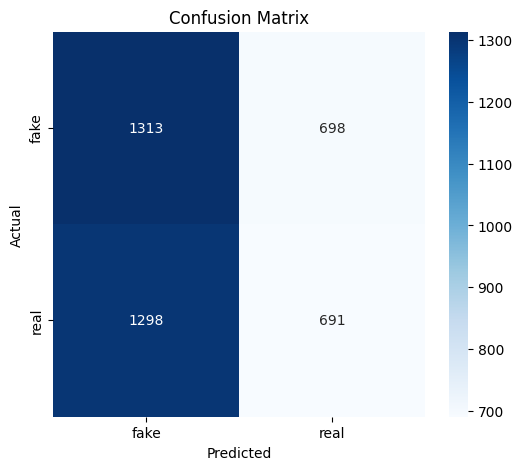

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['fake', 'real'],
    yticklabels=['fake', 'real']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 15. Testing Berita Baru

In [ ]:
news = """
Scientists discover a new renewable energy source
that can significantly reduce global carbon emissions.
"""

news_vector = tfidf.transform([news])

prediction = nb_model.predict(news_vector)

print("Prediction:", prediction[0])

Prediction: fake


# Fake News Detection using Support Vector Machine (SVM)

In [ ]:
# Import library yang diperlukan
import os
import re
import glob
import string
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)


## 1. Konfigurasi

In [ ]:
DATA_PATH = "fake_news_dataset.csv"

## 2. Load Dataset

In [ ]:
import kagglehub
import pandas as pd
import os
import glob

path = kagglehub.dataset_download(
    "mahdimashayekhi/fake-news-detection-dataset"
)

csv_file = glob.glob(os.path.join(path, "*.csv"))[0]

data = pd.read_csv(csv_file)

data.head()

100%|██████████| 11.2M/11.2M [00:00<00:00, 67.7MB/s]

Extracting files...


,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawyer hear outside continue reach difference yeah figure your power fear ...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next investment consumer range wrong exactly once attack shoulder movie partner...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk several front pull blood choose born prove we clear approach language ele...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where police identify either once participant not man human tough enough offer...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exactly pattern both sell training understand so ahead single western ago...,2023-04-03,CNN,Austin Walker,Technology,fake


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     20000 non-null  object
 1   text      20000 non-null  object
 2   date      20000 non-null  object
 3   source    19000 non-null  object
 4   author    19000 non-null  object
 5   category  20000 non-null  object
 6   label     20000 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB


In [ ]:
# Melihat nama kolom dan jumlah label
print("Columns:", list(data.columns))

possible_label_cols = [col for col in data.columns if col.lower() in ["label", "target", "class", "category"]]
if possible_label_cols:
    print("\nLabel distribution:")
    print(data[possible_label_cols[0]].value_counts(dropna=False))

Columns: ['title', 'text', 'date', 'source', 'author', 'category', 'label']

Label distribution:
category
Health           2922
Entertainment    2889
Technology       2882
Sports           2867
Business         2849
Politics         2802
Science          2789
Name: count, dtype: int64


## 3. Preprocessing Dataset


In [ ]:
def pick_column(df, candidates):
    """Ambil nama kolom berdasarkan kandidat nama kolom tanpa memperhatikan kapitalisasi."""
    lower_to_original = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    return None


def prepare_text_and_label(df):
    """Siapkan kolom text dan label dari dataset."""
    label_col = pick_column(df, ["label", "target", "class", "category"])
    title_col = pick_column(df, ["title", "headline", "news_title"])
    text_col = pick_column(df, ["text", "content", "article", "body", "statement", "news", "description"])

    if label_col is None:
        raise ValueError("Kolom label tidak ditemukan. Pastikan dataset memiliki kolom label/target/class/category.")

    if title_col is None and text_col is None:
        # fallback: gunakan kolom object terpanjang selain label
        object_cols = [col for col in df.select_dtypes(include="object").columns if col != label_col]
        if not object_cols:
            raise ValueError("Kolom teks tidak ditemukan.")
        text_col = max(object_cols, key=lambda col: df[col].astype(str).str.len().mean())

    prepared = df.copy()

    if title_col is not None and text_col is not None and title_col != text_col:
        prepared["combined_text"] = prepared[title_col].fillna("").astype(str) + " " + prepared[text_col].fillna("").astype(str)
        print(f"Text column: combined '{title_col}' + '{text_col}'")
    else:
        chosen_text_col = text_col if text_col is not None else title_col
        prepared["combined_text"] = prepared[chosen_text_col].fillna("").astype(str)
        print(f"Text column: '{chosen_text_col}'")

    prepared["raw_label"] = prepared[label_col]
    print(f"Label column: '{label_col}'")
    return prepared


def clean_text(text):
    """Membersihkan teks berita sebelum masuk ke TF-IDF."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URL
    text = re.sub(r"\S+@\S+", " ", text)                    # email
    text = re.sub(r"<.*?>", " ", text)                       # HTML
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)                         # angka
    text = re.sub(r"\s+", " ", text).strip()                 # spasi
    return text


def encode_label(label):
    """Encode label menjadi 0=fake/hoax dan 1=real/valid."""
    value = str(label).strip().lower()

    fake_values = {"fake", "false", "hoax", "hoaks", "palsu", "0"}
    real_values = {"real", "true", "valid", "benar", "1"}

    if value in fake_values:
        return 0
    if value in real_values:
        return 1

    # fallback untuk label numerik selain 0/1
    try:
        return int(float(value))
    except ValueError:
        raise ValueError(f"Label tidak dikenali: {label}")


prepared_data = prepare_text_and_label(data)
prepared_data["clean_text"] = prepared_data["combined_text"].apply(clean_text)
prepared_data["label"] = prepared_data["raw_label"].apply(encode_label)

# Hapus data kosong setelah cleaning
prepared_data = prepared_data[prepared_data["clean_text"].str.len() > 0].reset_index(drop=True)

prepared_data[["combined_text", "clean_text", "raw_label", "label"]].head()

Text column: combined 'title' + 'text'
Label column: 'label'


,combined_text,clean_text,raw_label,label
0,Foreign Democrat final. more tax development both store agreement lawyer hear outside continue reach difference yeah...,foreign democrat final more tax development both store agreement lawyer hear outside continue reach difference yeah ...,real,1
1,To offer down resource great point. probably guess western behind likely next investment consumer range wrong exactl...,to offer down resource great point probably guess western behind likely next investment consumer range wrong exactly...,fake,0
2,Himself church myself carry. them identify forward present success risk several front pull blood choose born prove w...,himself church myself carry them identify forward present success risk several front pull blood choose born prove we...,fake,0
3,You unit its should. phone which item yard Republican safe where police identify either once participant not man hum...,you unit its should phone which item yard republican safe where police identify either once participant not man huma...,fake,0
4,Billion believe employee summer how. wonder myself fact difficult course forget exactly pattern both sell training u...,billion believe employee summer how wonder myself fact difficult course forget exactly pattern both sell training un...,fake,0


In [ ]:
print("Jumlah data setelah preprocessing:", prepared_data.shape[0])
print("Distribusi label:")
print(prepared_data["label"].value_counts().sort_index().rename(index={0: "Fake/Hoax", 1: "Real/Valid"}))

Jumlah data setelah preprocessing: 20000
Distribusi label:
label
Fake/Hoax     10056
Real/Valid     9944
Name: count, dtype: int64


## 4. Split Data dan Ekstraksi Fitur


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    prepared_data["clean_text"],
    prepared_data["label"],
    test_size=0.2,
    random_state=42,
    stratify=prepared_data["label"]
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

xtr = vectorizer.fit_transform(X_train)
xte = vectorizer.transform(X_test)

ytr = y_train
yte = y_test

## 5. Training Model SVM


In [ ]:
from sklearn.svm import LinearSVC

clf = LinearSVC()
clf.fit(xtr, ytr)
y_pred = clf.predict(xte)

## 6. Evaluasi Model

Evaluasi yang ditampilkan:

- Accuracy
- Confusion matrix
- Classification report, berisi precision, recall, dan F1-score

In [ ]:
m = yte.shape[0]
n = (yte != y_pred).sum()
accuracy = (m - n) / m

print("Accuracy = " + format(accuracy * 100, ".2f") + "%")

Accuracy = 50.42%


In [ ]:
print("Classification Report:")
print(classification_report(yte, y_pred, target_names=["Fake/Hoax", "Real/Valid"]))

Classification Report:
              precision    recall  f1-score   support

   Fake/Hoax       0.51      0.53      0.52      2011
  Real/Valid       0.50      0.48      0.49      1989

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



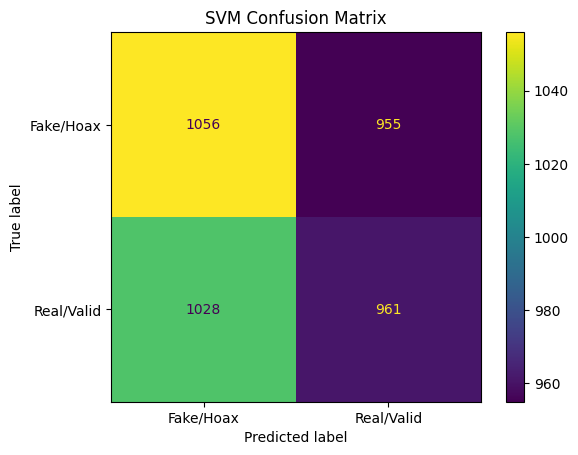

In [ ]:
def plot_cmat(y_true, y_predicted):
    """Plot confusion matrix, mengikuti fungsi plot_cmat pada svm.py."""
    cm = confusion_matrix(y_true, y_predicted)
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Fake/Hoax", "Real/Valid"],
    )
    display.plot(values_format="d")
    plt.title("SVM Confusion Matrix")
    plt.show()


plot_cmat(yte, y_pred)

## 7. Contoh Prediksi Berita Baru


In [ ]:
def predict_news(text):
    """Prediksi apakah sebuah teks berita termasuk fake/hoax atau real/valid."""
    cleaned = clean_text(text)
    features = vectorizer.transform([cleaned])
    prediction = clf.predict(features)[0]
    label_name = "Real/Valid" if prediction == 1 else "Fake/Hoax"
    return label_name


example_news = "Government announces new public health policy after official press conference."
print("Example prediction:", predict_news(example_news))

Example prediction: Fake/Hoax
